# UCRIS — Separate RF + XGBoost (Ablation)
## Unified Customer Risk Intelligence System

### Project Overview
Post-loan monitoring system that continuously analyzes customer
financial behavior to detect early signs of financial stress and
predict risk escalation before default occurs.

- **Dataset:** UCI Credit Card Default (30,000 customers, 25 features)
- **Approach:** Dual-task classification using engineered temporal features
- **Innovation:** Behavioral drift detection using 6-month payment history

---

### This Notebook — Separate RF + XGBoost (Ablation Study)

| Property | Detail |
|---|---|
| Role | Baseline Model 4 — ablation comparison |
| Tasks | Both Task A (stress) AND Task B (escalation) |
| Models | RF for stress + XGBoost for escalation independently |
| Purpose | Prove joint training beats separate training |

**What this notebook proves:**
This is the critical ablation study for the research paper
and patent. We take the best individual models (RF for stress,
XGBoost for escalation) and run them completely independently
on both tasks. The combined performance of these two separate
models sets the bar that the multi-task joint model must beat.

**The hypothesis being tested:**
Joint training with a shared encoder learns a better
representation than two independently trained models because
stress and escalation share underlying behavioral signals.
If the joint model outperforms this notebook's combined
results, the hypothesis is confirmed.

**Key difference from all previous notebooks:**
- We train TWO models in one notebook
- We evaluate BOTH tasks together
- We report a combined performance score
- No new model architecture — just best configs from 
  notebooks 02 and 03 run independently

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (train_test_split,
                                     StratifiedKFold,
                                     cross_val_score)
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score, recall_score,
                             precision_score,
                             roc_auc_score,
                             ConfusionMatrixDisplay)
import shap
import joblib
import os
import json
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
np.random.seed(42)

df_raw = pd.read_excel('../credit_default.csv',
                        header=1,
                        engine='xlrd')

print("✓ All imports successful")
print(f"✓ Dataset loaded: {df_raw.shape}")

✓ All imports successful
✓ Dataset loaded: (30000, 25)


In [2]:
print("=" * 55)
print("DATA PREPARATION — CLEAN + ENGINEER + BOTH LABELS")
print("=" * 55)

# ── Step 1: Clean ─────────────────────────────────────
df = df_raw.copy()
df = df.drop('ID', axis=1)
df = df.rename(columns={'default payment next month': 'default'})
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0:3})

pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                'PAY_AMT4','PAY_AMT5','PAY_AMT6']
for col in pay_amt_cols:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

print("✓ Cleaning complete")

# ── Step 2: Feature Engineering ───────────────────────
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
             'BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols  = ['PAY_0','PAY_2','PAY_3',
             'PAY_4','PAY_5','PAY_6']
x = np.arange(6)

for i, col in enumerate(bill_cols, 1):
    df[f'UTIL_{i}'] = (
        df[col] / df['LIMIT_BAL'].replace(0, np.nan)
    ).clip(0, 1).fillna(0)

util_cols = [f'UTIL_{i}' for i in range(1, 7)]
df['avg_utilization'] = df[util_cols].mean(axis=1)
df['util_recent']     = df[['UTIL_1','UTIL_2']].mean(axis=1)
df['util_early']      = df[['UTIL_5','UTIL_6']].mean(axis=1)
df['util_change']     = df['util_recent'] - df['util_early']

pay_matrix = df[pay_cols].values.astype(float)
df['pay_delay_trend'] = np.array([
    np.polyfit(x, row, 1)[0] for row in pay_matrix
])
df['avg_pay_delay']      = df[pay_cols].mean(axis=1)
df['consecutive_delays'] = df[pay_cols].gt(0).sum(axis=1)

for i, (p, b) in enumerate(zip(pay_amt_cols, bill_cols), 1):
    df[f'REPAY_RATIO_{i}'] = np.where(
        df[b] > 0,
        (df[p] / df[b]).clip(0, 1),
        1.0
    )
repay_cols = [f'REPAY_RATIO_{i}' for i in range(1, 7)]
df['avg_repay_ratio'] = df[repay_cols].mean(axis=1)

df['spending_volatility'] = np.log1p(df[bill_cols].std(axis=1))
pay_amt_matrix = df[pay_amt_cols].values.astype(float)
df['pay_amt_trend'] = np.sign(
    np.array([np.polyfit(x, row, 1)[0]
               for row in pay_amt_matrix])
) * np.log1p(np.abs(
    np.array([np.polyfit(x, row, 1)[0]
               for row in pay_amt_matrix])
))

print("✓ Feature engineering complete")

# ── Step 3: Both Labels ───────────────────────────────
def assign_stress_label(row):
    if row['PAY_0'] >= 2 or row['avg_utilization'] > 0.80:
        return 2
    elif (row['PAY_0'] == 1 or
          (0.50 < row['avg_utilization'] <= 0.80)):
        return 1
    else:
        return 0

def assign_escalation_label(row):
    pay_recent       = (row['PAY_0'] + row['PAY_2']) / 2
    pay_early        = (row['PAY_5'] + row['PAY_6']) / 2
    delay_escalating = pay_recent > pay_early
    util_escalating  = row['util_change'] > 0.15
    return 1 if (delay_escalating or util_escalating) else 0

df['stress_label']     = df.apply(assign_stress_label, axis=1)
df['escalation_label'] = df.apply(assign_escalation_label, axis=1)

stress_map = {0: 'Low', 1: 'Medium', 2: 'High'}
print("✓ Both labels engineered")

# ── Step 4: Feature Selection + Encoding ──────────────
temporal_features    = [
    'avg_utilization', 'util_change', 'avg_pay_delay',
    'consecutive_delays', 'avg_repay_ratio',
    'spending_volatility', 'pay_delay_trend',
    'pay_amt_trend', 'LIMIT_BAL'
]
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']
feature_cols         = temporal_features + categorical_features

df_model = df[feature_cols +
              ['stress_label', 'escalation_label',
               'default']].copy()
df_model = pd.get_dummies(df_model,
                           columns=categorical_features,
                           drop_first=True)

feature_columns = [c for c in df_model.columns
                   if c not in ['stress_label',
                                'escalation_label',
                                'default']]

X = df_model[feature_columns]

# ── Both targets ──────────────────────────────────────
y_stress     = df_model['stress_label']
y_escalation = df_model['escalation_label']

# scale_pos_weight for XGBoost escalation model
neg = (y_escalation == 0).sum()
pos = (y_escalation == 1).sum()
scale_pos_weight = (neg / pos) * 1.5

# ── SAME random_state=42 split for fair comparison ────
# Critical — both models must be tested on identical
# test sets to make the ablation comparison valid
X_train, X_test, y_stress_train, y_stress_test, \
y_esc_train, y_esc_test = train_test_split(
    X, y_stress, y_escalation,
    test_size=0.2,
    random_state=42,
    stratify=y_stress
)

print(f"\n── Summary ─────────────────────────────────────────")
print(f"  X_train       : {X_train.shape}")
print(f"  X_test        : {X_test.shape}")
print(f"  Features      : {feature_columns}")
print(f"\n  Task A — Stress label distribution (train):")
for k, v in sorted(y_stress_train.value_counts().items()):
    pct = v / len(y_stress_train) * 100
    print(f"    {stress_map[k]:8s}: {v:,} ({pct:.1f}%)")
print(f"\n  Task B — Escalation label distribution (train):")
for k, v in sorted(y_esc_train.value_counts().items()):
    label = 'Stable' if k == 0 else 'Escalating'
    pct   = v / len(y_esc_train) * 100
    print(f"    {label:12s}: {v:,} ({pct:.1f}%)")
print(f"\n  scale_pos_weight: {scale_pos_weight:.4f}")
print(f"\n✓ Data ready — same split for both models")
print(f"  (ensures fair ablation comparison)")

DATA PREPARATION — CLEAN + ENGINEER + BOTH LABELS
✓ Cleaning complete
✓ Feature engineering complete
✓ Both labels engineered

── Summary ─────────────────────────────────────────
  X_train       : (24000, 15)
  X_test        : (6000, 15)
  Features      : ['avg_utilization', 'util_change', 'avg_pay_delay', 'consecutive_delays', 'avg_repay_ratio', 'spending_volatility', 'pay_delay_trend', 'pay_amt_trend', 'LIMIT_BAL', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']

  Task A — Stress label distribution (train):
    Low     : 12,259 (51.1%)
    Medium  : 6,216 (25.9%)
    High    : 5,525 (23.0%)

  Task B — Escalation label distribution (train):
    Stable      : 13,329 (55.5%)
    Escalating  : 10,671 (44.5%)

  scale_pos_weight: 1.8642

✓ Data ready — same split for both models
  (ensures fair ablation comparison)


In [3]:
print("=" * 55)
print("TRAINING BOTH MODELS — BEST CONFIGS FROM NB 02 & 03")
print("=" * 55)

# ── Model A: Random Forest for Stress (from NB 02) ────
print("\n── Training Model A: Random Forest (Stress) ────────")
print("  Config: 300 trees, depth=30, features=0.5,")
print("          balanced, no bootstrap")

rf_stress = RandomForestClassifier(
    n_estimators   = 300,
    max_depth      = 30,
    max_features   = 0.5,
    class_weight   = 'balanced',
    bootstrap      = False,
    random_state   = 42,
    n_jobs         = -1
)
rf_stress.fit(X_train, y_stress_train)
print("  ✓ Random Forest trained on stress labels")

# Quick CV check
cv = StratifiedKFold(n_splits=5, shuffle=True,
                     random_state=42)
rf_cv = cross_val_score(
    rf_stress, X_train, y_stress_train,
    cv=cv, scoring='f1_weighted', n_jobs=-1
)
print(f"  CV F1 (5-fold): {rf_cv.mean():.4f} "
      f"± {rf_cv.std():.4f}")

# ── Model B: XGBoost for Escalation (from NB 03) ──────
print("\n── Training Model B: XGBoost (Escalation) ──────────")
print("  Config: 500 trees, depth=7, lr=0.2,")
print("          scale_pos_weight=1.864")

xgb_esc = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 7,
    learning_rate     = 0.2,
    subsample         = 0.6,
    colsample_bytree  = 0.9,
    min_child_weight  = 7,
    gamma             = 0,
    reg_alpha         = 0,
    reg_lambda        = 0.5,
    scale_pos_weight  = scale_pos_weight,
    random_state      = 42,
    eval_metric       = 'logloss',
    verbosity         = 0
)
xgb_esc.fit(X_train, y_esc_train)
print("  ✓ XGBoost trained on escalation labels")

xgb_cv = cross_val_score(
    xgb_esc, X_train, y_esc_train,
    cv=cv, scoring='recall', n_jobs=-1
)
print(f"  CV Recall (5-fold): {xgb_cv.mean():.4f} "
      f"± {xgb_cv.std():.4f}")

print(f"\n✓ Both models trained independently")
print(f"  No shared representation — pure ablation baseline")

TRAINING BOTH MODELS — BEST CONFIGS FROM NB 02 & 03

── Training Model A: Random Forest (Stress) ────────
  Config: 300 trees, depth=30, features=0.5,
          balanced, no bootstrap
  ✓ Random Forest trained on stress labels
  CV F1 (5-fold): 0.9838 ± 0.0018

── Training Model B: XGBoost (Escalation) ──────────
  Config: 500 trees, depth=7, lr=0.2,
          scale_pos_weight=1.864
  ✓ XGBoost trained on escalation labels
  CV Recall (5-fold): 0.9941 ± 0.0013

✓ Both models trained independently
  No shared representation — pure ablation baseline


COMBINED EVALUATION — BOTH TASKS

── TASK A: STRESS DETECTION (Random Forest) ────────
              precision    recall  f1-score   support

         Low     0.9905    0.9896    0.9900      3065
      Medium     0.9707    0.9794    0.9750      1554
        High     0.9898    0.9819    0.9858      1381

    accuracy                         0.9852      6000
   macro avg     0.9837    0.9836    0.9836      6000
weighted avg     0.9852    0.9852    0.9852      6000

── TASK B: ESCALATION DETECTION (XGBoost) ──────────
              precision    recall  f1-score   support

      Stable     0.9970    0.9970    0.9970      3295
  Escalating     0.9963    0.9963    0.9963      2705

    accuracy                         0.9967      6000
   macro avg     0.9966    0.9966    0.9966      6000
weighted avg     0.9967    0.9967    0.9967      6000


COMBINED ABLATION SCORE

  Task A — Stress Weighted F1 : 0.9852
  Task B — Escalation Recall  : 0.9963
  ────────────────────────────────────────
  Com

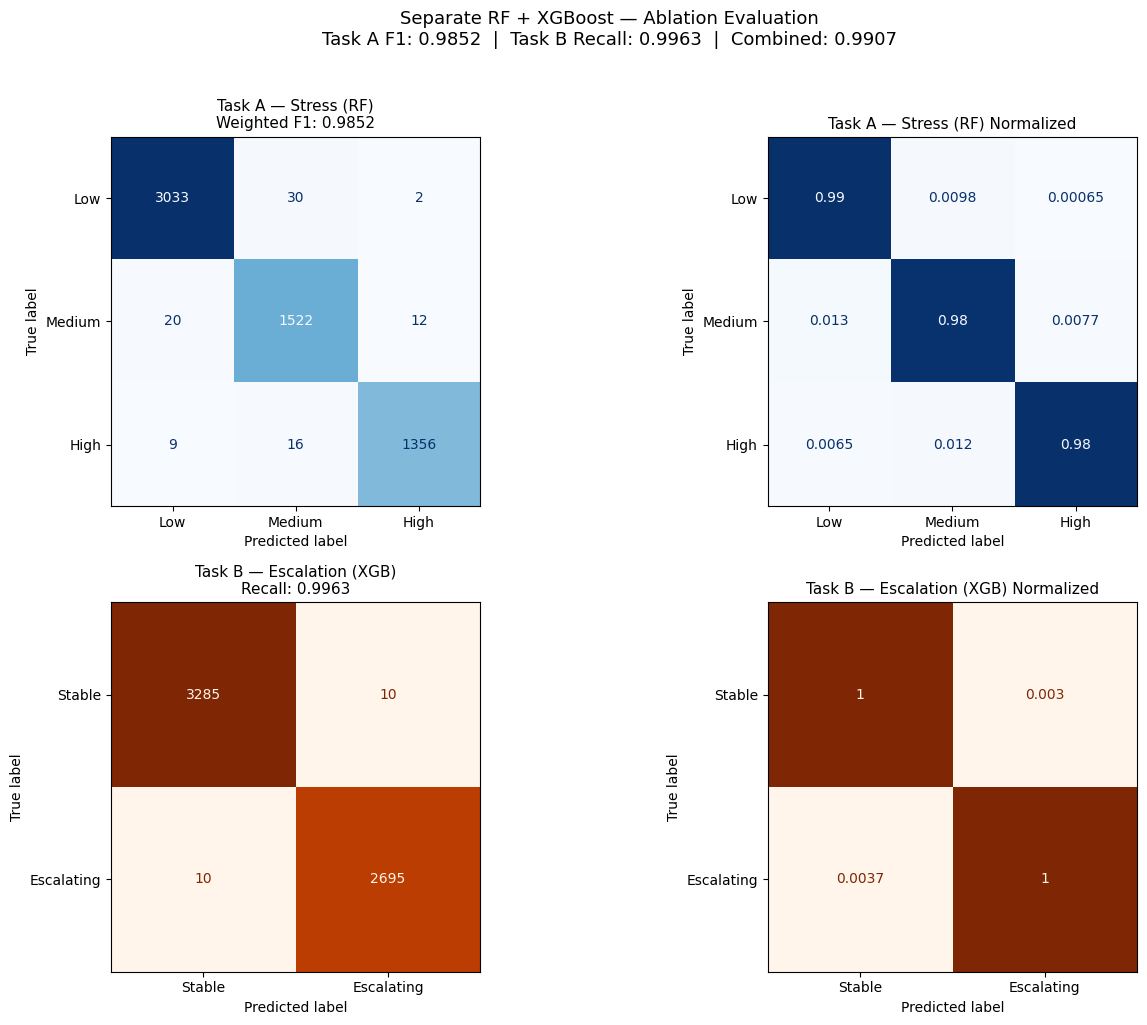


── Error Analysis ──────────────────────────────────

  Task A (Stress):
    Total errors : 89 / 6,000
    Error rate   : 1.48%
    F1 per class :
      Low     : 0.9900
      Medium  : 0.9750
      High    : 0.9858

  Task B (Escalation):
    False Negatives (missed): 10
    False Positives (alarms): 10
    Error rate              : 0.33%

ABLATION BENCHMARK — FOR JOINT MODEL COMPARISON

  ┌─────────────────────────────────────────────────┐
  │  SEPARATE MODELS BASELINE (Ablation Model 4)    │
  ├─────────────────────────────────────────────────┤
  │  Task A — Stress Detection (RF)                 │
  │    Weighted F1  : 0.9852                    │
  │    F1 Low       : 0.9900                    │
  │    F1 Medium    : 0.9750                    │
  │    F1 High      : 0.9858                    │
  ├─────────────────────────────────────────────────┤
  │  Task B — Escalation Detection (XGB)            │
  │    Recall       : 0.9963                    │
  │    Precision    : 0.9963     

In [4]:
print("=" * 55)
print("COMBINED EVALUATION — BOTH TASKS")
print("=" * 55)

# ── Task A: Stress predictions ────────────────────────
y_stress_pred      = rf_stress.predict(X_test)
y_stress_pred_prob = rf_stress.predict_proba(X_test)

# ── Task B: Escalation predictions ───────────────────
y_esc_pred      = xgb_esc.predict(X_test)
y_esc_pred_prob = xgb_esc.predict_proba(X_test)[:, 1]

print("\n── TASK A: STRESS DETECTION (Random Forest) ────────")
print(classification_report(
    y_stress_test, y_stress_pred,
    target_names=['Low', 'Medium', 'High'],
    digits=4
))

stress_f1_weighted  = f1_score(
    y_stress_test, y_stress_pred, average='weighted'
)
stress_f1_macro     = f1_score(
    y_stress_test, y_stress_pred, average='macro'
)
stress_f1_per_class = f1_score(
    y_stress_test, y_stress_pred, average=None
)

print(f"── TASK B: ESCALATION DETECTION (XGBoost) ──────────")
print(classification_report(
    y_esc_test, y_esc_pred,
    target_names=['Stable', 'Escalating'],
    digits=4
))

esc_recall    = recall_score(y_esc_test, y_esc_pred)
esc_precision = precision_score(y_esc_test, y_esc_pred)
esc_f1        = f1_score(y_esc_test, y_esc_pred)
esc_auc       = roc_auc_score(y_esc_test, y_esc_pred_prob)

# ── Combined Score ────────────────────────────────────
# Combined score = average of primary metrics
# Task A primary: weighted F1
# Task B primary: recall
# This is what joint model must beat on BOTH metrics
combined_score = (stress_f1_weighted + esc_recall) / 2

print(f"\n{'='*55}")
print(f"COMBINED ABLATION SCORE")
print(f"{'='*55}")
print(f"\n  Task A — Stress Weighted F1 : {stress_f1_weighted:.4f}")
print(f"  Task B — Escalation Recall  : {esc_recall:.4f}")
print(f"  {'─'*40}")
print(f"  Combined Score (avg)        : {combined_score:.4f}")
print(f"\n  This is the benchmark the joint model must beat")
print(f"  on BOTH tasks simultaneously")

# ── Confusion Matrices ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Task A
stress_cm = confusion_matrix(y_stress_test, y_stress_pred)
ConfusionMatrixDisplay(
    confusion_matrix=stress_cm,
    display_labels=['Low', 'Medium', 'High']
).plot(ax=axes[0][0], cmap='Blues', colorbar=False)
axes[0][0].set_title(
    f'Task A — Stress (RF)\nWeighted F1: {stress_f1_weighted:.4f}',
    fontsize=11
)

stress_cm_norm = confusion_matrix(
    y_stress_test, y_stress_pred, normalize='true'
)
ConfusionMatrixDisplay(
    confusion_matrix=stress_cm_norm,
    display_labels=['Low', 'Medium', 'High']
).plot(ax=axes[0][1], cmap='Blues', colorbar=False)
axes[0][1].set_title(
    'Task A — Stress (RF) Normalized',
    fontsize=11
)

# Task B
esc_cm = confusion_matrix(y_esc_test, y_esc_pred)
ConfusionMatrixDisplay(
    confusion_matrix=esc_cm,
    display_labels=['Stable', 'Escalating']
).plot(ax=axes[1][0], cmap='Oranges', colorbar=False)
axes[1][0].set_title(
    f'Task B — Escalation (XGB)\nRecall: {esc_recall:.4f}',
    fontsize=11
)

esc_cm_norm = confusion_matrix(
    y_esc_test, y_esc_pred, normalize='true'
)
ConfusionMatrixDisplay(
    confusion_matrix=esc_cm_norm,
    display_labels=['Stable', 'Escalating']
).plot(ax=axes[1][1], cmap='Oranges', colorbar=False)
axes[1][1].set_title(
    'Task B — Escalation (XGB) Normalized',
    fontsize=11
)

plt.suptitle(
    f'Separate RF + XGBoost — Ablation Evaluation\n'
    f'Task A F1: {stress_f1_weighted:.4f}  |  '
    f'Task B Recall: {esc_recall:.4f}  |  '
    f'Combined: {combined_score:.4f}',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

# ── Error Analysis Both Tasks ─────────────────────────
print(f"\n── Error Analysis ──────────────────────────────────")
stress_errors = (y_stress_test != y_stress_pred).sum()
esc_fn        = esc_cm[1][0]
esc_fp        = esc_cm[0][1]

print(f"\n  Task A (Stress):")
print(f"    Total errors : {stress_errors:,} / {len(y_stress_test):,}")
print(f"    Error rate   : {stress_errors/len(y_stress_test)*100:.2f}%")
print(f"    F1 per class :")
for i, cls in enumerate(['Low', 'Medium', 'High']):
    print(f"      {cls:8s}: {stress_f1_per_class[i]:.4f}")

print(f"\n  Task B (Escalation):")
print(f"    False Negatives (missed): {esc_fn:,}")
print(f"    False Positives (alarms): {esc_fp:,}")
print(f"    Error rate              : "
      f"{(y_esc_test != y_esc_pred).sum()/len(y_esc_test)*100:.2f}%")

# ── Benchmark Summary ─────────────────────────────────
print(f"\n{'='*55}")
print(f"ABLATION BENCHMARK — FOR JOINT MODEL COMPARISON")
print(f"{'='*55}")
print(f"""
  ┌─────────────────────────────────────────────────┐
  │  SEPARATE MODELS BASELINE (Ablation Model 4)    │
  ├─────────────────────────────────────────────────┤
  │  Task A — Stress Detection (RF)                 │
  │    Weighted F1  : {stress_f1_weighted:.4f}                    │
  │    F1 Low       : {stress_f1_per_class[0]:.4f}                    │
  │    F1 Medium    : {stress_f1_per_class[1]:.4f}                    │
  │    F1 High      : {stress_f1_per_class[2]:.4f}                    │
  ├─────────────────────────────────────────────────┤
  │  Task B — Escalation Detection (XGB)            │
  │    Recall       : {esc_recall:.4f}                    │
  │    Precision    : {esc_precision:.4f}                    │
  │    F1           : {esc_f1:.4f}                    │
  │    AUC          : {esc_auc:.4f}                    │
  ├─────────────────────────────────────────────────┤
  │  COMBINED SCORE : {combined_score:.4f}                    │
  ├─────────────────────────────────────────────────┤
  │  Joint model must exceed these on BOTH tasks    │
  │  simultaneously to validate the contribution    │
  └─────────────────────────────────────────────────┘
""")

# ── Save both models ──────────────────────────────────
print("=" * 55)
print("SAVING BOTH MODELS")
print("=" * 55)

os.makedirs('../models/separate_rf_xgboost', exist_ok=True)

joblib.dump(rf_stress,
    '../models/separate_rf_xgboost/rf_stress.pkl')
joblib.dump(xgb_esc,
    '../models/separate_rf_xgboost/xgb_escalation.pkl')
joblib.dump(feature_columns,
    '../models/separate_rf_xgboost/feature_columns.pkl')

metadata = {
    "model"          : "Separate RF + XGBoost (Ablation)",
    "tasks"          : {
        "A" : "Stress Detection — Random Forest",
        "B" : "Escalation Detection — XGBoost"
    },
    "date_trained"   : datetime.now().strftime("%Y-%m-%d"),
    "test_metrics"   : {
        "task_a_weighted_f1" : round(
            float(stress_f1_weighted), 4),
        "task_a_f1_low"      : round(
            float(stress_f1_per_class[0]), 4),
        "task_a_f1_medium"   : round(
            float(stress_f1_per_class[1]), 4),
        "task_a_f1_high"     : round(
            float(stress_f1_per_class[2]), 4),
        "task_b_recall"      : round(float(esc_recall), 4),
        "task_b_precision"   : round(
            float(esc_precision), 4),
        "task_b_f1"          : round(float(esc_f1), 4),
        "task_b_auc"         : round(float(esc_auc), 4),
        "combined_score"     : round(float(combined_score), 4)
    },
    "features_used"  : feature_columns,
    "notes"          : [
        "Ablation Model 4 — separate independent training",
        "No shared representation between tasks",
        "Sets benchmark for joint model comparison",
        "Combined score is average of Task A F1 + Task B Recall"
    ]
}

with open(
    '../models/separate_rf_xgboost/metadata.json', 'w'
) as f:
    json.dump(metadata, f, indent=2)

print("✓ RF stress model saved")
print("✓ XGB escalation model saved")
print("✓ Metadata saved")